In [11]:
library(ggplot2)
library(tidyverse)
library(ggpubr)

In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
# indir=""
# outdir=""

In [2]:
options(repr.plot.width=45/25.4,repr.plot.height=45/25.4,repr.plot.res=400)

In [ ]:
data = read.csv(paste0(indir,'/data_60kb_bin_by_cell_for_Etl4.csv'))

In [4]:
data2 = data[c('subclass_label','X5hmCG_chr2_19690000_19750000', 'X5mCG_chr2_19690000_19750000', 'ENSMUSG00000036617.16')]

In [5]:
data3 = data2[data2$'subclass_label' %in% c('OB-STR-CTX Inh IMN', 'STR D1 Gaba', 'L6 CT CTX Glut', 'L5 NP CTX Glut'),]
colnames(data3) = c('subclass_label', 'X5hmCG', 'X5mCG', 'RNA')
data3$'true5mCG'=pmax(data3$'X5mCG'-data3$'X5hmCG', 0)
data3$'subclass_label' <- factor(data3$'subclass_label', levels = c('L5 NP CTX Glut', 'L6 CT CTX Glut', 'STR D1 Gaba', 'OB-STR-CTX Inh IMN'))

In [6]:
head(data3)

,subclass_label,X5hmCG,X5mCG,RNA,true5mCG
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
4,L6 CT CTX Glut,0.3571429,0.8333333,2.9606767,0.4761904
10,L6 CT CTX Glut,0.0000000,NA,1.5863845,NA
29,STR D1 Gaba,0.2372881,0.9339623,2.0731099,0.6966742
39,L6 CT CTX Glut,NA,NA,3.4905479,NA
40,L6 CT CTX Glut,0.2467533,0.8282828,2.6644037,0.5815296
42,STR D1 Gaba,0.2307692,0.8068182,0.1399562,0.5760490


In [7]:
my_comparisons = list(c('L5 NP CTX Glut', 'L6 CT CTX Glut'),
                       c('L6 CT CTX Glut', 'STR D1 Gaba'),
                      c('STR D1 Gaba', 'OB-STR-CTX Inh IMN')
                      )

In [8]:
sum(data3$'subclass_label' == 'OB-STR-CTX Inh IMN')

[1] 225

In [9]:
sum(data3$'subclass_label' == 'STR D1 Gaba')

[1] 4840

pdf 
  2

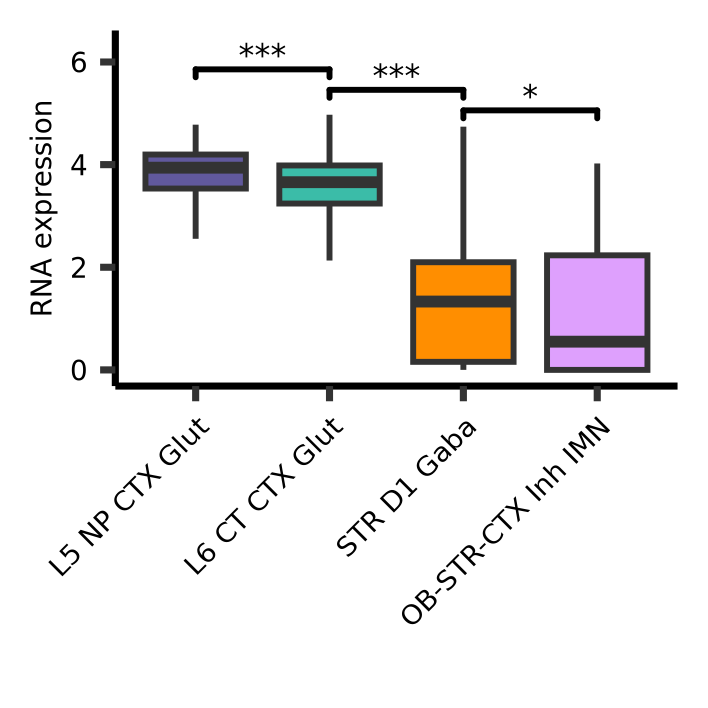

In [ ]:
pdf('../../../../output/01-youth/06-m3C_supplementary_figures/plots/08_barplot_RNA.pdf', width=45/25.4,height=45/25.4, family="ArialMT")

p <- ggplot(data=data3, aes(x=subclass_label, group=subclass_label,y=RNA,fill=subclass_label))+
geom_boxplot(outliers = FALSE)+
scale_fill_manual(values = c('L5 NP CTX Glut'='#61599d', 'L6 CT CTX Glut'='#3BBCA8', 'STR D1 Gaba'='#FF8E00', 'OB-STR-CTX Inh IMN'='#DEA0FD')) + # Set custom colors
theme_bw()+
labs(x='',y='RNA expression')+
theme(legend.position="none",
legend.title = element_text(size = 5),  # Change legend title size
legend.text = element_text(size = 5),   # Change legend text size
plot.title = element_text(hjust = 0.5,family="ArialMT"),
title = element_text(size=5,hjust = 0.5,family="ArialMT"),
axis.title.x = element_text(color="black", size=5,family="ArialMT"),
axis.title.y = element_text(color="black", size=5,family="ArialMT"),
axis.text.x = element_text(color="black", size=5,family="ArialMT", angle = 45, hjust = 1),
axis.text.y = element_text(color="black", size=5,family="ArialMT"),
axis.line=element_line(size=0.6),
axis.ticks=element_line(size=0.6),
panel.border=element_blank(),
panel.grid=element_blank())+
geom_signif(  comparisons = my_comparisons,  map_signif_level = TRUE, test = "wilcox.test", y_position = c(5.6,5.2,4.8), textsize = 2)+
ylim(c(0,6.3))
print(p)
dev.off()
print(p)

In [206]:
data3 %>% group_by(subclass_label) %>% summarise(mean_value = mean(RNA, na.rm = TRUE))

subclass_label,mean_value
<fct>,<dbl>
L5 NP CTX Glut,3.767746
L6 CT CTX Glut,3.516145
STR D1 Gaba,1.262738
OB-STR-CTX Inh IMN,1.172424


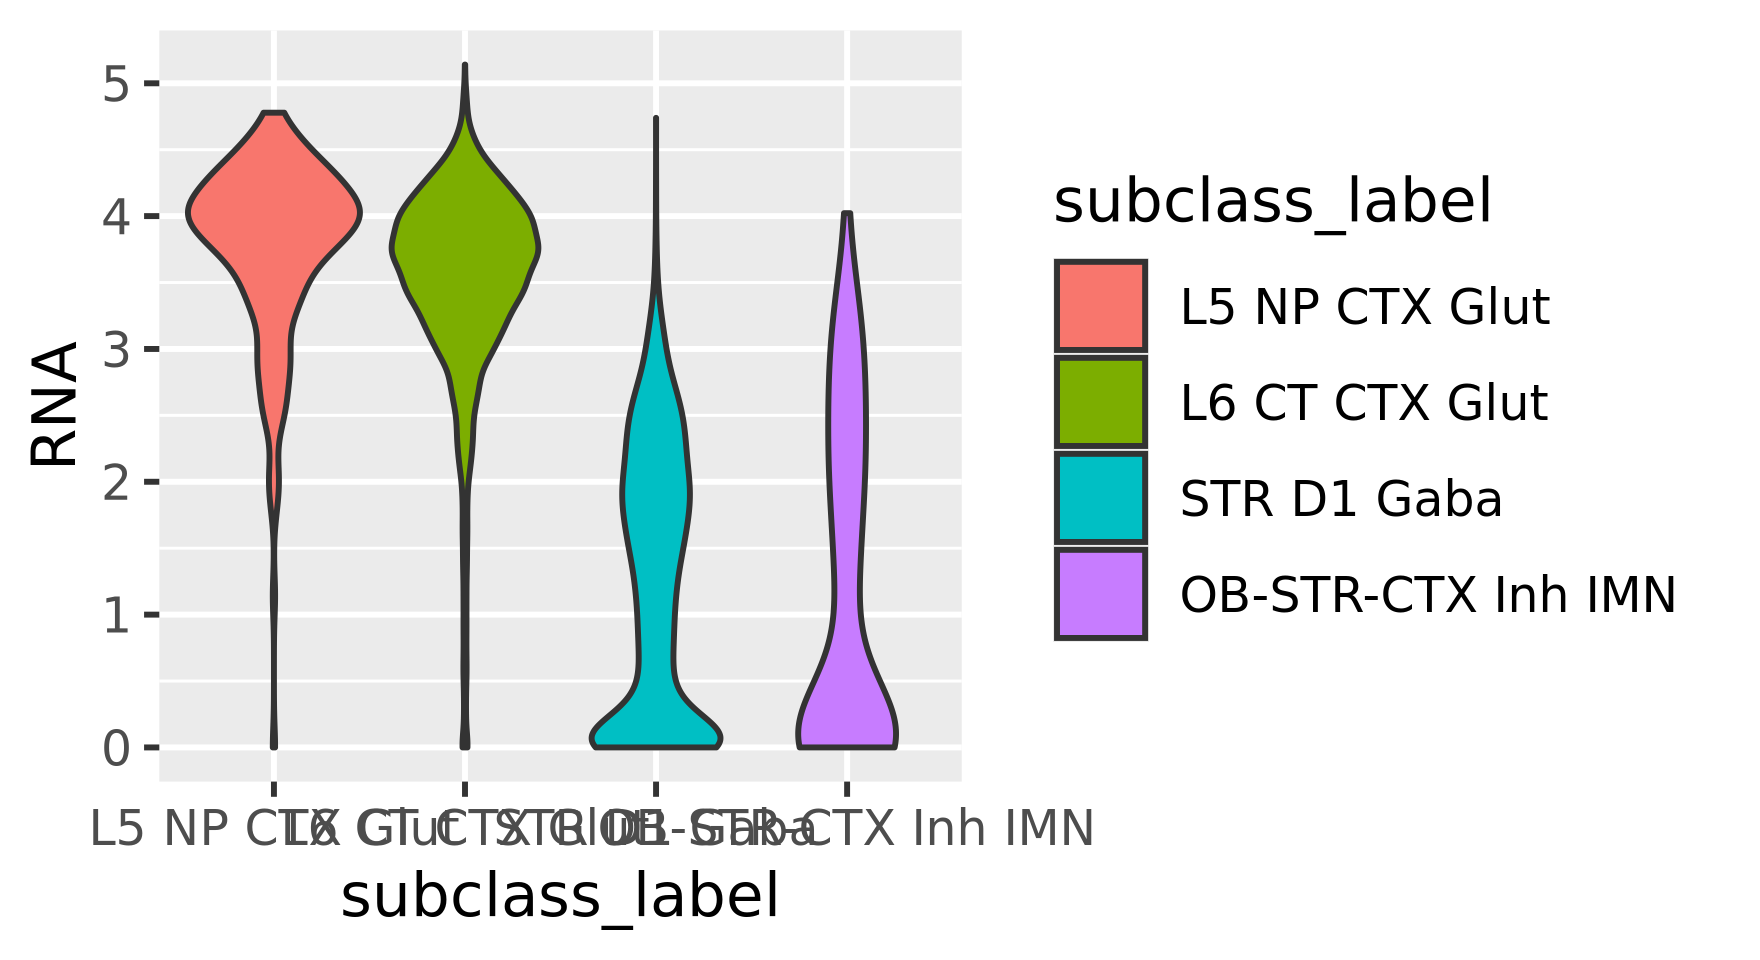

In [213]:
options(repr.plot.width=4.4,repr.plot.height=2.4,repr.plot.res=400)
ggplot(data=data3, aes(x=subclass_label, group=subclass_label,y=RNA,fill=subclass_label))+
geom_violin()

Warning message:
“Removed 1426 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1426 rows containing non-finite outside the scale range (`stat_signif()`).”


pdf 
  2

Warning message:
“Removed 1426 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1426 rows containing non-finite outside the scale range (`stat_signif()`).”


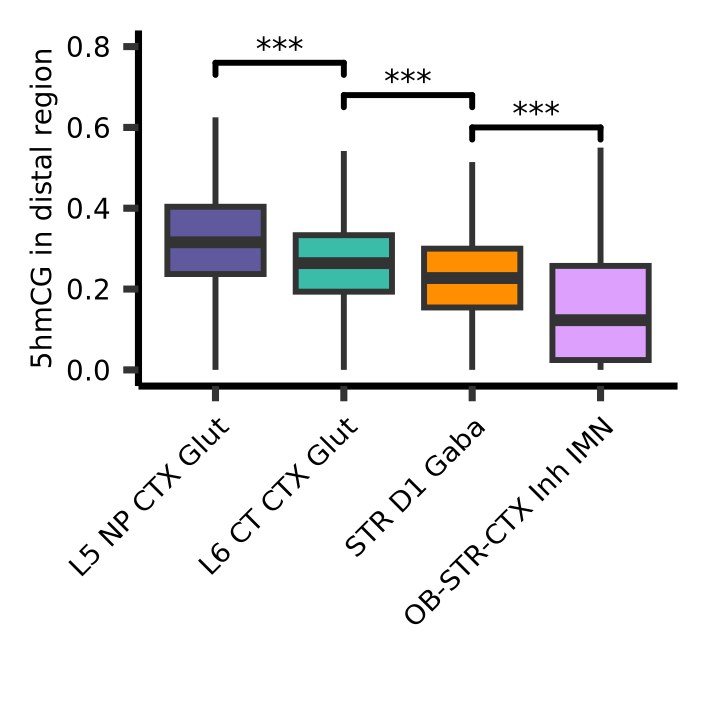

In [ ]:
pdf('../../../../output/01-youth/06-m3C_supplementary_figures/08_barplot_5hmCG.pdf', width=45/25.4,height=45/25.4, family="ArialMT")

p <- ggplot(data=data3, aes(x=subclass_label, group=subclass_label,y=X5hmCG,fill=subclass_label))+
geom_boxplot(outliers = FALSE)+
scale_fill_manual(values = c('L5 NP CTX Glut'='#61599d', 'L6 CT CTX Glut'='#3BBCA8', 'STR D1 Gaba'='#FF8E00', 'OB-STR-CTX Inh IMN'='#DEA0FD')) + # Set custom colors
theme_bw()+
labs(x='',y='5hmCG in distal region')+
theme(legend.position="none",
legend.title = element_text(size = 5),  # Change legend title size
legend.text = element_text(size = 5),   # Change legend text size
plot.title = element_text(hjust = 0.5,family="ArialMT"),
title = element_text(size=5,hjust = 0.5,family="ArialMT"),
axis.title.x = element_text(color="black", size=5,family="ArialMT"),
axis.title.y = element_text(color="black", size=5,family="ArialMT"),
axis.text.x = element_text(color="black", size=5,family="ArialMT", angle = 45, hjust = 1),
axis.text.y = element_text(color="black", size=5,family="ArialMT"),
axis.line=element_line(size=0.6),
axis.ticks=element_line(size=0.6),
panel.border=element_blank(),
panel.grid=element_blank())+
geom_signif(  comparisons = my_comparisons,  map_signif_level = TRUE, test = "wilcox.test", y_position = c(0.71,0.63,0.55), textsize = 2)+
ylim(c(0,0.8))

print(p)
dev.off()
print(p)

Warning message:
“Removed 1385 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1385 rows containing non-finite outside the scale range (`stat_signif()`).”


pdf 
  2

Warning message:
“Removed 1385 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1385 rows containing non-finite outside the scale range (`stat_signif()`).”


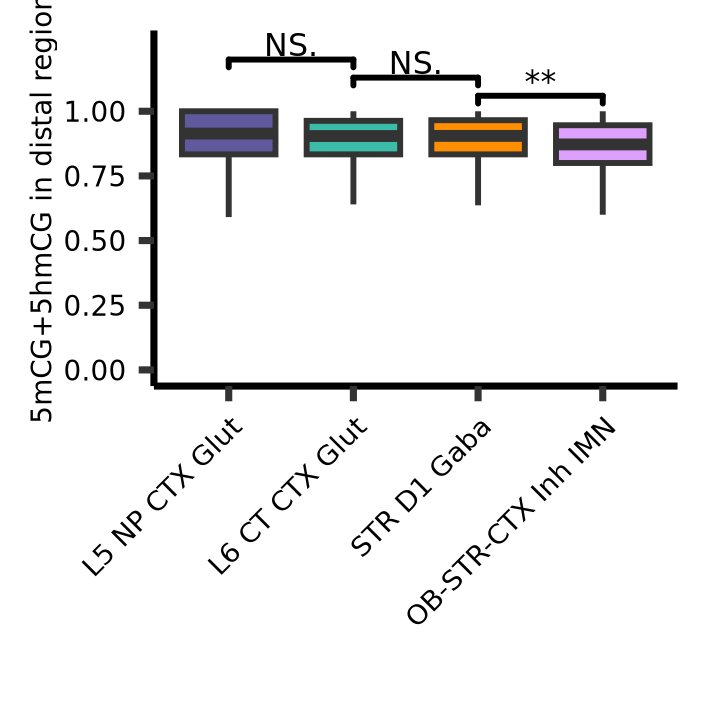

In [ ]:
pdf('../../../../output/01-youth/06-m3C_supplementary_figures/08_barplot_5mCG.pdf', width=45/25.4,height=45/25.4, family="ArialMT")

p <- ggplot(data=data3, aes(x=subclass_label, group=subclass_label,y=X5mCG,fill=subclass_label))+
geom_boxplot(outliers = FALSE)+
scale_fill_manual(values = c('L5 NP CTX Glut'='#61599d', 'L6 CT CTX Glut'='#3BBCA8', 'STR D1 Gaba'='#FF8E00', 'OB-STR-CTX Inh IMN'='#DEA0FD')) + # Set custom colors
theme_bw()+
labs(x='',y='5mCG+5hmCG in distal region')+
theme(legend.position="none",
legend.title = element_text(size = 5),  # Change legend title size
legend.text = element_text(size = 5),   # Change legend text size
plot.title = element_text(hjust = 0.5,family="ArialMT"),
title = element_text(size=5,hjust = 0.5,family="ArialMT"),
axis.title.x = element_text(color="black", size=5,family="ArialMT"),
axis.title.y = element_text(color="black", size=5,family="ArialMT"),
axis.text.x = element_text(color="black", size=5,family="ArialMT", angle = 45, hjust = 1),
axis.text.y = element_text(color="black", size=5,family="ArialMT"),
axis.line=element_line(size=0.6),
axis.ticks=element_line(size=0.6),
panel.border=element_blank(),
panel.grid=element_blank())+
geom_signif(  comparisons = my_comparisons,  map_signif_level = TRUE, test = "wilcox.test", y_position = c(1.15,1.08,1.01), textsize = 2,family="ArialMT")+
scale_y_continuous(limits = c(0, 1.25), breaks = seq(0, 1, by = 0.25))

print(p)
dev.off()
print(p)

Warning message:
“Removed 1730 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1730 rows containing non-finite outside the scale range (`stat_signif()`).”


pdf 
  2

Warning message:
“Removed 1730 rows containing non-finite outside the scale range (`stat_boxplot()`).”
Warning message:
“Removed 1730 rows containing non-finite outside the scale range (`stat_signif()`).”


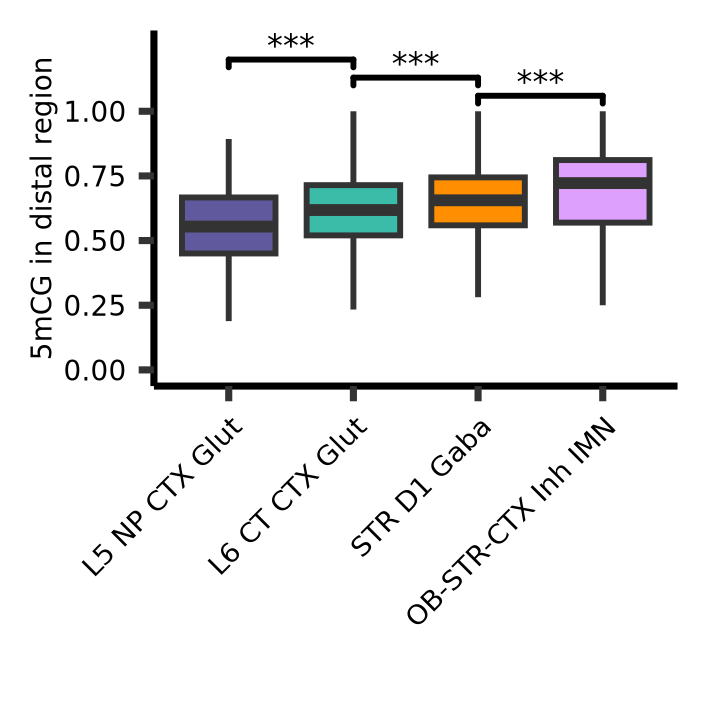

In [ ]:
pdf('../../../../output/01-youth/06-m3C_supplementary_figures/08_barplot_true5mCG.pdf', width=45/25.4,height=45/25.4, family="ArialMT")

p <- ggplot(data=data3, aes(x=subclass_label, group=subclass_label,y=true5mCG,fill=subclass_label))+
geom_boxplot(outliers = FALSE)+
scale_fill_manual(values = c('L5 NP CTX Glut'='#61599d', 'L6 CT CTX Glut'='#3BBCA8', 'STR D1 Gaba'='#FF8E00', 'OB-STR-CTX Inh IMN'='#DEA0FD')) + # Set custom colors
theme_bw()+
labs(x='',y='5mCG in distal region')+
theme(legend.position="none",
legend.title = element_text(size = 5),  # Change legend title size
legend.text = element_text(size = 5),   # Change legend text size
plot.title = element_text(hjust = 0.5,family="ArialMT"),
title = element_text(size=5,hjust = 0.5,family="ArialMT"),
axis.title.x = element_text(color="black", size=5,family="ArialMT"),
axis.title.y = element_text(color="black", size=5,family="ArialMT"),
axis.text.x = element_text(color="black", size=5,family="ArialMT", angle = 45, hjust = 1),
axis.text.y = element_text(color="black", size=5,family="ArialMT"),
axis.line=element_line(size=0.6),
axis.ticks=element_line(size=0.6),
panel.border=element_blank(),
panel.grid=element_blank())+
geom_signif(  comparisons = my_comparisons,  map_signif_level = TRUE, test = "wilcox.test", y_position = c(1.15,1.08,1.01), textsize = 2)+
scale_y_continuous(limits = c(0, 1.25), breaks = seq(0, 1, by = 0.25))

print(p)
dev.off()
print(p)

In [173]:
t.test(data3[data3$'subclass_label' == 'STR D1 Gaba',]$'true5mCG', data3[data3$'subclass_label' == 'DG Glut',]$'true5mCG', alternative = 'two.sided')


	Welch Two Sample t-test

data:  data3[data3$subclass_label == "STR D1 Gaba", ]$true5mCG and data3[data3$subclass_label == "DG Glut", ]$true5mCG
t = 3.8422, df = 3579.5, p-value = 0.0001241
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 0.009188792 0.028338719
sample estimates:
mean of x mean of y 
0.6438690 0.6251052 
